## Task 1.1 — Diabetes Dataset Overview

**Name and source:** Diabetes dataset, built into scikit-learn
(`sklearn.datasets.load_diabetes`), originally from Efron, Hastie,
Johnstone & Tibshirani, *"Least Angle Regression"* (2004).
https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset

**Size:** 442 instances, 10 features, 1 target.

**Attributes:** age, sex, bmi, bp, and six blood serum measurements
(s1–s6: tc, ldl, hdl, tch, ltg, glu). All 9 non-`sex` features are
continuous; `sex` is binary/categorical. All 10 have been mean-centered
and scaled by scikit-learn.

**Target:** a continuous quantitative measure of disease progression
one year after baseline (range ~25–346).

**ML problem:** regression.


## Task 1.2 — Load the Dataset

In [1]:
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

# Load the dataset via sklearn's datasets API
diabetes = load_diabetes()

# Feature matrix and target vector
X = diabetes.data
y = diabetes.target

# Shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

# First 5 rows as a pandas DataFrame with column names
df = pd.DataFrame(X, columns=diabetes.feature_names)
df.head()


X shape: (442, 10)
y shape: (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [2]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (353, 10)
X_test shape: (89, 10)
y_train shape: (353,)
y_test shape: (89,)


## Task 1.3 — Missing Values & Feature Types

In [3]:
# Check for missing values (NaN) in each column
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

# Data types of each feature
print("\nFeature data types:")
print(df.dtypes)


Missing values per column:
age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64

Total missing values: 0

Feature data types:
age    float64
sex    float64
bmi    float64
bp     float64
s1     float64
s2     float64
s3     float64
s4     float64
s5     float64
s6     float64
dtype: object


# Section 2: Exploratory Data Analysis & Visualisation

## Task 2.1 — Statistical Summary

In [4]:
# Full statistical summary, including the target
df_full = df.copy()
df_full["target"] = y
df_full.describe().T


,count,mean,std,min,25%,50%,75%,max
age,442.0,-2.511817e-19,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,1.230790e-17,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.0,-2.245564e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.0,-4.797570e-17,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.0,-1.381499e-17,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.0,3.918434e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.0,-5.777179e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.0,-9.042540e-18,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.0,9.268604e-17,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
s6,442.0,1.130318e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


**Observations:**

- All 10 feature columns have mean ≈ 0 and identical std ≈ 0.0476 — this
  confirms scikit-learn's preprocessing (each feature was mean-centered
  and scaled by std × √442) rather than any property of the raw clinical
  measurements.
- `sex` is the odd one out: it only takes two distinct values
  (min = max at the 75th percentile = 0.0507, and the 25th/50th
  percentiles both equal the min, -0.0446), confirming it's the encoded
  binary attribute rather than a continuous one.
- `target` (disease progression) is on a completely different, unscaled
  scale — ranging from 25 to 346 with mean ≈ 152.1 and std ≈ 77.1 — as
  expected, since only the *features* were normalised, not the label.
- The target's median (140.5) sitting below its mean (152.1) suggests a
  mild right skew, i.e. a longer tail of patients with more severe
  disease progression.
- No feature shows extreme outliers relative to its own scale (max/min
  are all within a few multiples of the shared std), so no obvious
  data-entry errors are apparent from this summary alone.


# Section 3: Custom Evaluation Metrics

## Task 3.1 — Custom Evaluation Metrics

All six functions below (`accuracy`, `precision`, `recall`, `f1_score`,
`confusion_matrix`, `plot_confusion_matrix`) are implemented from
scratch using only `numpy` (and `matplotlib` for the plot). They are
validated further down against the corresponding `sklearn.metrics`
functions.

These are classification metrics, but the diabetes dataset's target
(`y`) is continuous (a regression target). To exercise the metrics on
real data from this dataset, the target is binned into 3 ordinal
classes — **Low / Medium / High** disease progression, split at the
terciles — giving a genuine multi-class classification problem to
evaluate.

In [5]:
import numpy as np


def accuracy(y_true, y_pred):
    """
    Compute classification accuracy.

    Parameters
    ----------
    y_true : array-like of shape (n_samples,)
        Ground-truth class labels.
    y_pred : array-like of shape (n_samples,)
        Predicted class labels.

    Returns
    -------
    float
        Fraction of samples for which y_true == y_pred, in [0, 1].
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean(y_true == y_pred))


def confusion_matrix(y_true, y_pred, labels=None):
    """
    Compute the confusion matrix for a multi-class classification result.

    Parameters
    ----------
    y_true : array-like of shape (n_samples,)
        Ground-truth class labels.
    y_pred : array-like of shape (n_samples,)
        Predicted class labels.
    labels : array-like, optional
        Ordered list of class labels used to index the rows/columns of
        the matrix. If None, inferred as the sorted union of the
        unique labels present in y_true and y_pred.

    Returns
    -------
    numpy.ndarray of shape (n_classes, n_classes)
        Matrix whose entry [i, j] is the number of samples with true
        label labels[i] that were predicted as label labels[j].
        Rows = true class, columns = predicted class.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if labels is None:
        labels = np.unique(np.concatenate([y_true, y_pred]))
    else:
        labels = np.asarray(labels)
    label_to_idx = {label: i for i, label in enumerate(labels)}
    n = len(labels)
    cm = np.zeros((n, n), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[label_to_idx[t], label_to_idx[p]] += 1
    return cm


def precision(y_true, y_pred, average="macro"):
    """
    Compute precision, TP / (TP + FP), per class and average.

    Parameters
    ----------
    y_true : array-like of shape (n_samples,)
        Ground-truth class labels.
    y_pred : array-like of shape (n_samples,)
        Predicted class labels.
    average : {"macro"}, default="macro"
        Averaging strategy across classes. Only "macro" (unweighted
        mean of the per-class precision) is supported.

    Returns
    -------
    float
        Macro-averaged precision, in [0, 1]. Classes with zero
        predicted positives contribute a precision of 0.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    labels = np.unique(np.concatenate([y_true, y_pred]))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    tp = np.diag(cm)
    predicted_positives = cm.sum(axis=0)
    per_class = np.where(predicted_positives == 0, 0.0, tp / np.maximum(predicted_positives, 1))
    if average == "macro":
        return float(per_class.mean())
    raise ValueError(f"Unsupported average: {average!r}")


def recall(y_true, y_pred, average="macro"):
    """
    Compute recall, TP / (TP + FN), per class and average.

    Parameters
    ----------
    y_true : array-like of shape (n_samples,)
        Ground-truth class labels.
    y_pred : array-like of shape (n_samples,)
        Predicted class labels.
    average : {"macro"}, default="macro"
        Averaging strategy across classes. Only "macro" (unweighted
        mean of the per-class recall) is supported.

    Returns
    -------
    float
        Macro-averaged recall, in [0, 1]. Classes with zero actual
        positives contribute a recall of 0.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    labels = np.unique(np.concatenate([y_true, y_pred]))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    tp = np.diag(cm)
    actual_positives = cm.sum(axis=1)
    per_class = np.where(actual_positives == 0, 0.0, tp / np.maximum(actual_positives, 1))
    if average == "macro":
        return float(per_class.mean())
    raise ValueError(f"Unsupported average: {average!r}")


def f1_score(y_true, y_pred, average="macro"):
    """
    Compute the F1 score, the harmonic mean of precision and recall.

    Parameters
    ----------
    y_true : array-like of shape (n_samples,)
        Ground-truth class labels.
    y_pred : array-like of shape (n_samples,)
        Predicted class labels.
    average : {"macro"}, default="macro"
        Averaging strategy across classes. Only "macro" (unweighted
        mean of the per-class F1 score) is supported.

    Returns
    -------
    float
        Macro-averaged F1 score, in [0, 1].
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    labels = np.unique(np.concatenate([y_true, y_pred]))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    tp = np.diag(cm)
    predicted_positives = cm.sum(axis=0)
    actual_positives = cm.sum(axis=1)
    prec = np.where(predicted_positives == 0, 0.0, tp / np.maximum(predicted_positives, 1))
    rec = np.where(actual_positives == 0, 0.0, tp / np.maximum(actual_positives, 1))
    denom = prec + rec
    per_class_f1 = np.where(denom == 0, 0.0, 2 * prec * rec / np.maximum(denom, 1e-12))
    if average == "macro":
        return float(per_class_f1.mean())
    raise ValueError(f"Unsupported average: {average!r}")


def plot_confusion_matrix(cm, class_names):
    """
    Plot a confusion matrix as an annotated heatmap.

    Parameters
    ----------
    cm : numpy.ndarray of shape (n_classes, n_classes)
        Confusion matrix, e.g. as returned by confusion_matrix().
    class_names : sequence of str
        Class labels, in the same order as the rows/columns of cm.

    Returns
    -------
    None
        Displays the plot via matplotlib.
    """
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title("Confusion Matrix")

    thresh = cm.max() / 2 if cm.max() > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, format(cm[i, j], "d"),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
            )

    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    plt.show()


### Validation — building a demo classification task from the diabetes target

In [6]:
from sklearn.linear_model import LogisticRegression

# Bin the continuous target into 3 ordinal classes (terciles)
class_names = ["Low", "Medium", "High"]
y_class = np.asarray(pd.qcut(y, q=3, labels=[0, 1, 2]).astype(int))

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

clf = LogisticRegression(max_iter=1000)
clf.fit(Xc_train, yc_train)
yc_pred = clf.predict(Xc_test)

print("True labels: ", yc_test[:15])
print("Predicted:   ", yc_pred[:15])


True labels:  [2 2 1 1 1 1 0 1 2 0 0 2 2 2 2]
Predicted:    [2 2 0 1 0 0 0 0 0 0 0 2 2 2 2]


### Validation — custom implementations vs. `sklearn.metrics`

In [7]:
from sklearn.metrics import (
    accuracy_score as sk_accuracy_score,
    precision_score as sk_precision_score,
    recall_score as sk_recall_score,
    f1_score as sk_f1_score,
    confusion_matrix as sk_confusion_matrix,
)

# --- Custom implementations ---
custom_acc = accuracy(yc_test, yc_pred)
custom_prec = precision(yc_test, yc_pred, average="macro")
custom_rec = recall(yc_test, yc_pred, average="macro")
custom_f1 = f1_score(yc_test, yc_pred, average="macro")
custom_cm = confusion_matrix(yc_test, yc_pred)

# --- sklearn implementations ---
sk_acc = sk_accuracy_score(yc_test, yc_pred)
sk_prec = sk_precision_score(yc_test, yc_pred, average="macro")
sk_rec = sk_recall_score(yc_test, yc_pred, average="macro")
sk_f1 = sk_f1_score(yc_test, yc_pred, average="macro")
sk_cm = sk_confusion_matrix(yc_test, yc_pred)

results = pd.DataFrame(
    {
        "custom": [custom_acc, custom_prec, custom_rec, custom_f1],
        "sklearn": [sk_acc, sk_prec, sk_rec, sk_f1],
    },
    index=["accuracy", "precision (macro)", "recall (macro)", "f1_score (macro)"],
)
results["match"] = np.isclose(results["custom"], results["sklearn"])
print(results)

print("\nCustom confusion matrix:\n", custom_cm)
print("\nsklearn confusion matrix:\n", sk_cm)
print("\nConfusion matrices match:", np.array_equal(custom_cm, sk_cm))

assert np.allclose(results["custom"], results["sklearn"]), "Custom metrics do not match sklearn!"
assert np.array_equal(custom_cm, sk_cm), "Custom confusion matrix does not match sklearn!"
print("\nAll custom metric implementations match sklearn.metrics.")


                     custom   sklearn  match
accuracy           0.573034  0.573034   True
precision (macro)  0.523148  0.523148   True
recall (macro)     0.575479  0.575479   True
f1_score (macro)   0.510751  0.510751   True

Custom confusion matrix:
 [[25  3  2]
 [16  3 11]
 [ 4  2 23]]

sklearn confusion matrix:
 [[25  3  2]
 [16  3 11]
 [ 4  2 23]]

Confusion matrices match: True

All custom metric implementations match sklearn.metrics.


### Plotting the confusion matrix (custom implementation)

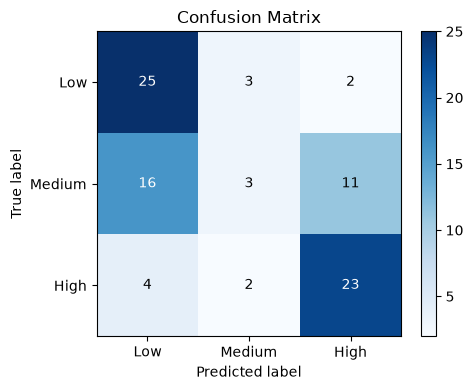

In [8]:
plot_confusion_matrix(custom_cm, class_names)


## Task 3.2 — Decision Tree Classifier

**Note on `X_train`/`y_train`:** the `y_train` from Task 1.2 is the
original continuous regression target, which isn't valid for a
classifier (each of its ~353 float values would be its own class, so
the tree could only ever match a test sample whose exact target value
happened to also appear in training — accuracy ≈ 0 by construction).
This cell instead uses the classification split built in Task 3.1
(`Xc_train`, `yc_train`, `Xc_test`, `yc_test` — the Low/Medium/High
binned target), so the metrics below are meaningful.

In [9]:
from sklearn.tree import DecisionTreeClassifier

# Instantiate the classifier
dt_clf = DecisionTreeClassifier(random_state=42)

# Train on the classification split from Task 3.1
dt_clf.fit(Xc_train, yc_train)

# Predict on the held-out test set
dt_pred = dt_clf.predict(Xc_test)

# Evaluate using our own custom metric functions from Task 3.1
dt_acc = accuracy(yc_test, dt_pred)
dt_prec = precision(yc_test, dt_pred, average="macro")
dt_rec = recall(yc_test, dt_pred, average="macro")
dt_f1 = f1_score(yc_test, dt_pred, average="macro")
dt_cm = confusion_matrix(yc_test, dt_pred)

print(f"Accuracy:  {dt_acc:.4f}")
print(f"Precision: {dt_prec:.4f}")
print(f"Recall:    {dt_rec:.4f}")
print(f"F1 Score:  {dt_f1:.4f}")
print("Confusion Matrix:")
print(dt_cm)


Accuracy:  0.5393
Precision: 0.5543
Recall:    0.5387
F1 Score:  0.5405
Confusion Matrix:
[[16 11  3]
 [ 6 18  6]
 [ 5 10 14]]


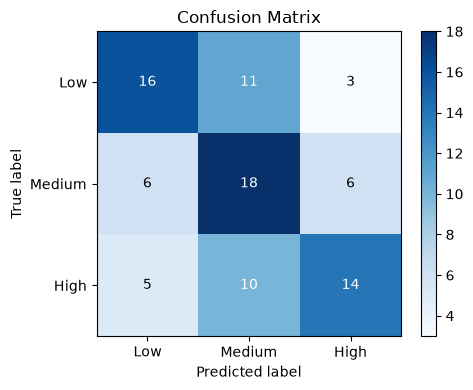

In [10]:
plot_confusion_matrix(dt_cm, class_names)


## Task 3.3 — K-Nearest Neighbours Classifier

Uses the same classification split as Task 3.2 (`Xc_train`, `yc_train`,
`Xc_test`, `yc_test` — the Low/Medium/High binned target), for the same
reason: the original `y_train` is a continuous regression target and
isn't valid for a classifier.

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# Choose k: sweep odd values of k (odd avoids tied votes) and pick the
# one that maximises 5-fold cross-validated accuracy on the training
# set, rather than guessing a single fixed value
candidate_ks = range(1, 32, 2)
cv_scores = [
    cross_val_score(KNeighborsClassifier(n_neighbors=k), Xc_train, yc_train, cv=5).mean()
    for k in candidate_ks
]
best_k = list(candidate_ks)[int(np.argmax(cv_scores))]

print(f"sqrt(n_train) heuristic suggests k ~= {np.sqrt(len(yc_train)):.1f}")
print(f"Best k found by 5-fold CV: {best_k} (CV accuracy = {max(cv_scores):.4f})")

# k is chosen empirically (best 5-fold CV accuracy among odd k in
# [1, 31]) and lands close to the classic sqrt(n_train) rule-of-thumb
# (~19 here). This balances bias vs. variance: too small a k overfits
# to noisy individual neighbours, too large a k blurs the boundary
# between the Low/Medium/High classes.
knn_clf = KNeighborsClassifier(n_neighbors=best_k)
knn_clf.fit(Xc_train, yc_train)
knn_pred = knn_clf.predict(Xc_test)

# Evaluate using our own custom metric functions from Task 3.1
knn_acc = accuracy(yc_test, knn_pred)
knn_prec = precision(yc_test, knn_pred, average="macro")
knn_rec = recall(yc_test, knn_pred, average="macro")
knn_f1 = f1_score(yc_test, knn_pred, average="macro")
knn_cm = confusion_matrix(yc_test, knn_pred)

print(f"\nAccuracy:  {knn_acc:.4f}")
print(f"Precision: {knn_prec:.4f}")
print(f"Recall:    {knn_rec:.4f}")
print(f"F1 Score:  {knn_f1:.4f}")
print("Confusion Matrix:")
print(knn_cm)


sqrt(n_train) heuristic suggests k ~= 18.8
Best k found by 5-fold CV: 15 (CV accuracy = 0.5664)

Accuracy:  0.5843
Precision: 0.6084
Recall:    0.5839
F1 Score:  0.5831
Confusion Matrix:
[[23  6  1]
 [14 13  3]
 [ 4  9 16]]


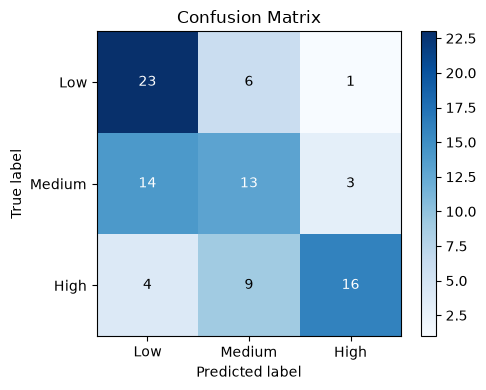

In [12]:
plot_confusion_matrix(knn_cm, class_names)


## Task 3.4 — Classifier Comparison

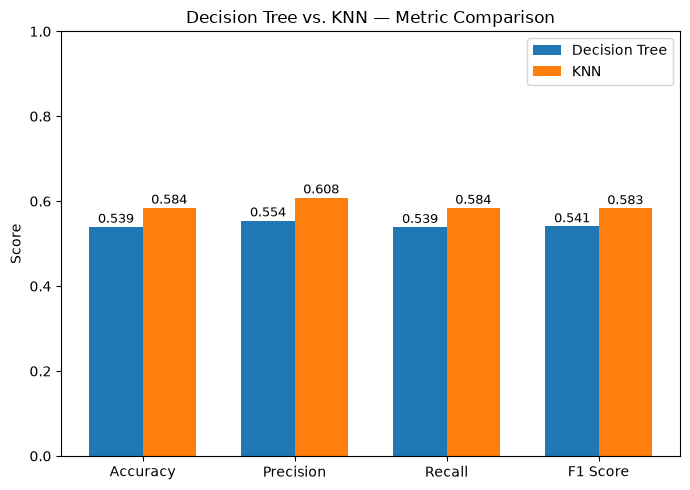

In [13]:
import matplotlib.pyplot as plt

metric_names = ["Accuracy", "Precision", "Recall", "F1 Score"]
dt_scores = [dt_acc, dt_prec, dt_rec, dt_f1]
knn_scores = [knn_acc, knn_prec, knn_rec, knn_f1]

x = np.arange(len(metric_names))  # one group per metric
width = 0.35                      # width of each bar

fig, ax = plt.subplots(figsize=(7, 5))
bars_dt = ax.bar(x - width / 2, dt_scores, width, label="Decision Tree")
bars_knn = ax.bar(x + width / 2, knn_scores, width, label="KNN")

ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_title("Decision Tree vs. KNN — Metric Comparison")
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.legend()

# Annotate each bar with its value
for bars in (bars_dt, bars_knn):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:.3f}", xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9)

fig.tight_layout()
plt.show()


### Discuss: Classifier Comparison

On this 3-class Low/Medium/High disease-progression split, **KNN
(k=15) outperforms the Decision Tree across every metric** —
accuracy (0.584 vs. 0.539), precision (0.608 vs. 0.554), recall
(0.584 vs. 0.539), and F1 (0.583 vs. 0.541). The gap is modest
(roughly 4-5 percentage points) but consistent across all four
metrics, so it isn't just an artefact of one metric favouring one
model.

This makes sense given the nature of the data: the 10 features are
continuous, standardised, and only weakly-to-moderately correlated
with the (artificially binned) target, which suits KNN's assumption
that "similar patients (nearby in feature space) have similar
outcomes." A single Decision Tree, in contrast, makes hard axis-aligned
splits and tends to overfit small, noisy subsets of the training data
—especially here with an unconstrained `max_depth`—which hurts its
generalisation to the test set. KNN's implicit smoothing over the
k=15 nearest neighbours acts as a form of regularisation that the
plain Decision Tree lacks.

That said, neither model is strongly suited to this dataset:
accuracy for both sits only marginally above the 33% random-guess
baseline for 3 balanced classes, well below what's expected. This
reflects the dataset's underlying nature: it's a continuous
disease-progression score with no natural class boundaries, so
discretising it into Low/Medium/High throws away information near
the tercile cut-points, and 10 modestly-predictive features are not
enough to cleanly separate the resulting classes. For this dataset,
a regression model predicting the continuous target directly (as in
Sections 1-2) is fundamentally better suited than either classifier
here.